
=== Generating Plot for Revised Particle Filter (Normal Duration Model) ===

Plot saved.


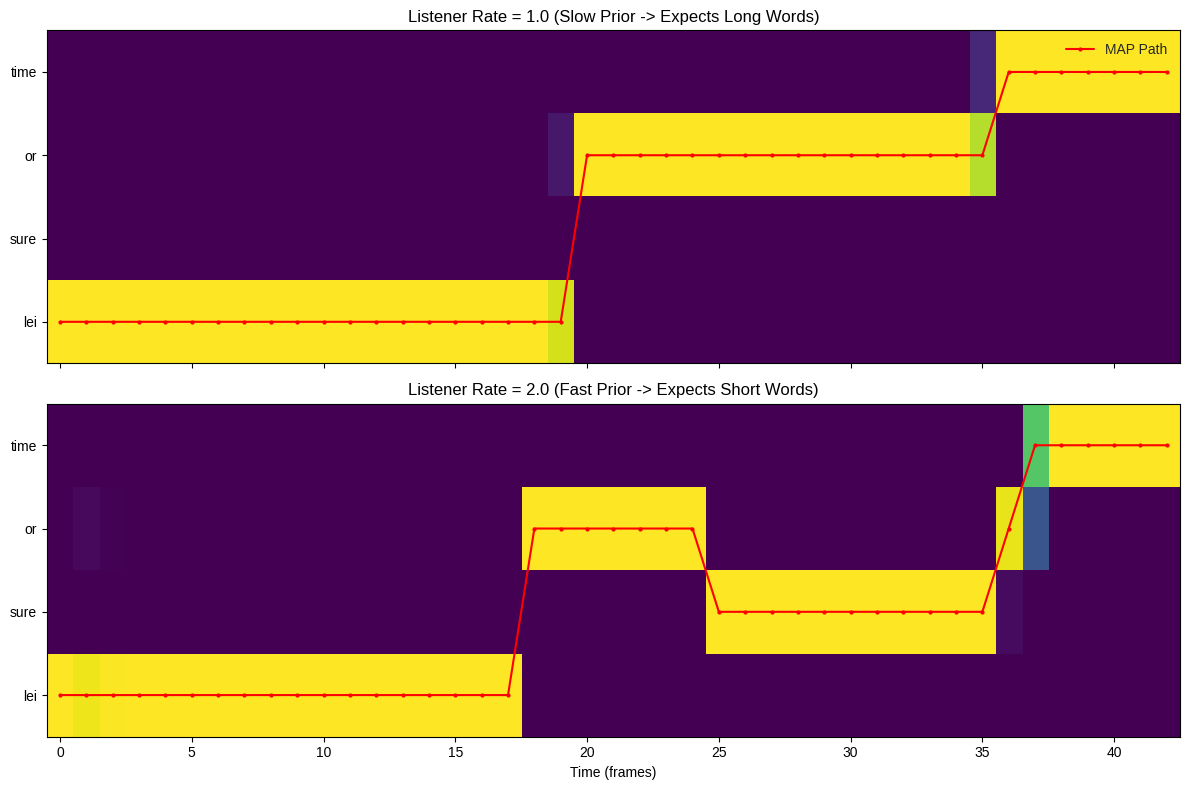

In [1]:
import numpy as np
from collections import Counter
from scipy.stats import norm
import matplotlib.pyplot as plt
import copy

# Keep seeds for reproducibility
np.random.seed(7)

# -------------------------------------------------------------------------
# 1. SETUP: States, Emissions, and Speaker
# -------------------------------------------------------------------------
STATES = ["START", "lei", "sure", "or", "time", "STOP"]
EMIT_STATES = ["lei", "sure", "or", "time"]
i = {s: k for k, s in enumerate(STATES)}
state_indices = {k: s for k, s in enumerate(STATES)}

# Base durations in frames (canonical mean duration)
def sample_base_durations(seed=None):
    rng = np.random.default_rng(seed)
    durations = {
        "lei":  max(5, int(rng.normal(loc=20, scale=0))),
        "sure": max(5, int(rng.normal(loc=20, scale=0))),
        "or":   max(3, int(rng.normal(loc=10, scale=0))),
        "time": max(5, int(rng.normal(loc=20, scale=0)))
    }
    return durations

BASE_DURATIONS = sample_base_durations(seed=42)

# Emissions
mu = {"lei": -1.0, "sure": 0.15, "or": 0.05, "time": 1.0}
sigma = {s: 0.3 for s in EMIT_STATES}

# Speaker Transitions (Deterministic for generation)
def make_speaker_pi_bar():
    n = len(STATES)
    T = np.zeros((n, n))
    T[i["START"], i["lei"]] = 1.0
    T[i["lei"], i["sure"]] = 1.0
    T[i["sure"], i["or"]] = 1.0
    T[i["or"], i["time"]] = 1.0
    T[i["time"], i["STOP"]] = 1.0
    T[i["STOP"], i["STOP"]] = 1.0
    return T

speaker_pi_bar = make_speaker_pi_bar()

# Listener Structural Transitions (Probabilistic - Word to Word)
# This defines P(W_i | W_{i-1})
def make_listener_pi_bar(uniform_eps=0.0):
    n = len(STATES)
    T = np.zeros((n, n))

    def row_with_primary(from_s, primary):
        row = np.zeros(n)
        used = 0.0
        for to_s, w in primary.items():
            row[i[to_s]] += w
            used += w
        # Distribute leftover
        leftover = max(0.0, 1.0 - used)
        mask = np.ones(n, dtype=bool)
        for to_s in primary.keys(): mask[i[to_s]] = False
        mask[i["START"]] = False
        if from_s == "STOP":
            mask[:] = False
            mask[i["STOP"]] = True

        count = mask.sum()
        if count > 0 and leftover > 0:
            row[mask] += leftover / count
        if uniform_eps > 0:
            row += uniform_eps
        return row / row.sum()

    T[i["START"]] = row_with_primary("START", {"lei": 0.97})
    T[i["lei"]]   = row_with_primary("lei",   {"sure": 0.94})
    # Crucially, listener allows skipping "or"
    T[i["sure"]]  = row_with_primary("sure",  {"or": 0.55, "time": 0.40})
    T[i["or"]]    = row_with_primary("or",    {"time": 0.95})
    T[i["time"]]  = row_with_primary("time",  {"STOP": 0.96})
    T[i["STOP"]]  = row_with_primary("STOP",  {"STOP": 1.0})
    return T

listener_pi_bar = make_listener_pi_bar()

# Sigmoid Kappa (ONLY used for SPEAKER generation now)
def sigmoid_kappa(t_elapsed, duration, steepness):
    return 1 / (1 + np.exp(steepness * (t_elapsed - duration)))

# Simulate Speaker (Generative Process)
def simulate_one_dynamic(rate, speaker_steepness, max_frames=1000, rng=None):
    if rng is None: rng = np.random.default_rng()
    s = "START"
    states, emissions = [], []
    dwell_time = 0
    frame = 0
    while frame < max_frames:
        if s in {"START", "STOP"}:
            probs = speaker_pi_bar[i[s]]
        else:
            effective_duration = BASE_DURATIONS[s] / rate
            kappa_t = sigmoid_kappa(dwell_time, effective_duration, speaker_steepness)
            row = speaker_pi_bar[i[s]].copy()
            row = (1 - kappa_t) * row
            row[i[s]] += kappa_t
            probs = row / row.sum()

        s_next = rng.choice(STATES, p=probs)
        if s_next == "STOP": break

        dwell_time = dwell_time + 1 if s_next == s else 1
        s = s_next
        states.append(s)
        if s in EMIT_STATES:
            emissions.append(rng.normal(loc=mu[s], scale=sigma[s]))
        frame += 1
    return states, np.array(emissions).reshape(-1, 1)

# -------------------------------------------------------------------------
# 2. NEW LISTENER: Particle Filter with "Lifted" Weight Calculation
# -------------------------------------------------------------------------

# Emission Log Probs Helper
def emission_log_probs(a_data):
    T = len(a_data)
    n = len(STATES)
    logp = np.full((T, n), -np.inf)
    for t in range(T):
        for s in EMIT_STATES:
            logp[t, i[s]] = norm.logpdf(a_data[t, 0], loc=mu[s], scale=sigma[s])
    return logp

# Resampling Helper
def systematic_resample(particles, weights):
    N = len(particles)
    new_particles = []
    positions = (np.arange(N) + np.random.rand()) / N
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            new_particles.append(copy.deepcopy(particles[j]))
            i += 1
        else:
            j += 1
            if j == N: j = N - 1
    return new_particles, np.full(N, 1.0/N)

# Updated Particle Class
class Particle:
    def __init__(self, state_idx, log_weight, history=None, log_acoustic=0.0):
        self.state_idx = state_idx
        self.log_weight = log_weight
        # History stores indices of states visited
        self.history = history if history is not None else []
        # Accumulated acoustic likelihood P(y|s)
        self.log_acoustic = log_acoustic

# Helper: Lift state history to (Word, Duration) sequence
def lift_to_words(state_history_indices):
    words = []
    if not state_history_indices:
        return words

    current_idx = state_history_indices[0]
    duration = 0

    for idx in state_history_indices:
        if idx == current_idx:
            duration += 1
        else:
            words.append((state_indices[current_idx], duration))
            current_idx = idx
            duration = 1

    # Append the final current word
    words.append((state_indices[current_idx], duration))
    return words

# Helper: Calculate Log Prior for Words + Durations
def calc_structural_prior(word_seq, rate):
    log_prob = 0.0

    # 1. Word Transitions P(W_i | W_{i-1})
    for k in range(1, len(word_seq)):
        prev_word, _ = word_seq[k-1]
        curr_word, _ = word_seq[k]

        # Get transition prob from listener_pi_bar
        # Note: listener_pi_bar is a state-to-state matrix.
        # Since states mapping to words are unique here, we can use it directly.
        p_trans = listener_pi_bar[i[prev_word], i[curr_word]]

        # Safety for log(0)
        if p_trans == 0:
            return -np.inf
        log_prob += np.log(p_trans)

    # 2. Durations P(d_i | W_i, r)
    for (word, d_frames) in word_seq:
        if word in ["START", "STOP"]:
            continue

        d_base = BASE_DURATIONS[word]
        # The mentor specified: Normal distribution
        # Mean = D_base
        # Std = D_base / 10
        # Observed 'canonical' duration = d_frames * rate

        d_canonical = d_frames * rate

        # Calculate normal log pdf
        # P(d_canonical | N(d_base, d_base/10))
        lp_dur = norm.logpdf(d_canonical, loc=d_base, scale=d_base/10.0)
        log_prob += lp_dur

    return log_prob

# Main Decoder
def particle_filter_decode(a_data, rate, num_particles=200, resampling_threshold=0.5, rng=None):
    if rng is None: rng = np.random.default_rng()

    T_len = len(a_data)
    n_states = len(STATES)
    log_emit = emission_log_probs(a_data)

    # Initialize
    particles = []
    init_log_w = np.log(1.0/num_particles)
    start_probs = listener_pi_bar[i["START"]]

    # Initial particles start in a state following START
    start_indices = rng.choice(n_states, size=num_particles, p=start_probs)

    for s_idx in start_indices:
        # t=0 acoustic likelihood
        la = log_emit[0, s_idx]
        # History starts with this state
        p = Particle(s_idx, init_log_w + la, history=[s_idx], log_acoustic=la)
        particles.append(p)

    state_dists = np.zeros((T_len, n_states))

    for t in range(T_len):

        # --- Record Distribution ---
        ws = np.array([p.log_weight for p in particles])
        max_w = np.max(ws)
        if np.isinf(max_w):
            norm_w = np.full(num_particles, 1.0/num_particles)
        else:
            norm_w = np.exp(ws - max_w)
            norm_w /= np.sum(norm_w)

        for p_idx, p in enumerate(particles):
            state_dists[t, p.state_idx] += norm_w[p_idx]

        if t == T_len - 1: break

        # --- Propagate & Update ---
        next_log_weights = []

        # Proposal Distribution Parameters
        # We need particles to explore durations, so we enforce a high self-transition probability
        # in the *proposal* step. The actual probability of that duration is handled by the weight.
        PROPOSAL_STAY_PROB = 0.8

        for p in particles:
            curr_idx = p.state_idx

            # 1. PROPOSE Next State
            # Flip coin to stay or switch
            if rng.random() < PROPOSAL_STAY_PROB:
                next_idx = curr_idx
            else:
                # If switching, choose from valid transitions in structural matrix
                # Renormalize row to exclude self-transition (if any) to ensure a switch happens here?
                # listener_pi_bar usually has 0 diagonal, so it forces a switch.
                # We just sample from listener_pi_bar[curr_idx]
                next_idx = rng.choice(n_states, p=listener_pi_bar[curr_idx])

            # 2. Update History
            p.history.append(next_idx)
            p.state_idx = next_idx

            # 3. Update Acoustic Likelihood (Cumulative)
            # LogLik_new = LogLik_old + log P(y_{t+1} | s_{t+1})
            emit_prob = log_emit[t+1, next_idx]
            p.log_acoustic += emit_prob

            # 4. Calculate Structural Prior (Fresh)
            word_seq = lift_to_words(p.history)
            log_struct_prior = calc_structural_prior(word_seq, rate)

            # 5. Total Weight
            # w ~ P(y|s) * P(s)
            new_log_w = p.log_acoustic + log_struct_prior

            p.log_weight = new_log_w
            next_log_weights.append(new_log_w)

        # --- Normalize & Resample ---
        next_log_weights = np.array(next_log_weights)
        max_log = np.max(next_log_weights)

        # Guard against numerical instability
        if np.isinf(max_log):
            # If all -inf (impossible paths), reset to uniform (soft reset)
            current_weights = np.full(num_particles, 1.0/num_particles)
            for p in particles: p.log_weight = np.log(1.0/num_particles)
        else:
            # Standard softmax normalization
            w_unorm = np.exp(next_log_weights - max_log)
            current_weights = w_unorm / np.sum(w_unorm)

        # Resample if ESS is low
        ess = 1.0 / np.sum(current_weights**2)
        if ess < num_particles * resampling_threshold:
            particles, current_weights = systematic_resample(particles, current_weights)
            # Reset log weights to uniform after resampling?
            # In SIR filters, resampling results in equal-weight particles.
            # However, we need to preserve the path history probabilities for the next step.
            # Actually, standard PF: resampled particles have weight 1/N.
            # But our weight calculation is "fresh" global probability.
            # If we reset weight to 1/N, we lose the accumulated acoustic likelihood
            # relative to other paths?
            #
            # Wait, the formula is w_t propto P(y_{0:t}, s_{0:t}).
            # If we resample, we select high-probability paths and duplicate them.
            # The *future* steps will continue to add to log_acoustic and re-eval prior.
            # So we DO need to keep the internal accumulators (log_acoustic, history) intact.
            # But the *current step's* weight for the loop becomes uniform.
            reset_val = np.log(1.0/num_particles)
            for p in particles:
                p.log_weight = reset_val # Used only for next resampling check?
                # No, p.log_weight is overwritten in step 5 next iter.
                # So setting it here is just for consistency.
                pass

    # MAP Path
    map_path_idx = np.argmax(state_dists, axis=1)
    map_path = [state_indices[x] for x in map_path_idx]
    return map_path, state_dists

# -------------------------------------------------------------------------
# 3. Plotting Function (Modified to use new decoder)
# -------------------------------------------------------------------------
def plot_particle_filter_comparison():
    print("\n=== Generating Plot for Revised Particle Filter (Normal Duration Model) ===\n")

    # Generate Data (Speaker uses old stickiness model - kept as requested)
    rng_sim = np.random.default_rng(123)
    rng_pf = np.random.default_rng(5678)
    rate_gen = 1.5
    SPEAKER_STEEPNESS = 0.5

    # Find a good ambiguous example
    while True:
        _, audio = simulate_one_dynamic(rate_gen, SPEAKER_STEEPNESS, rng=rng_sim)
        if 40 < len(audio) < 60: break

    # Decode
    # Note: Listener steepness param is removed, replaced by implicit Normal variance
    path_slow, dist_slow = particle_filter_decode(audio, rate=1.0, num_particles=300, rng=rng_pf)
    path_fast, dist_fast = particle_filter_decode(audio, rate=2.0, num_particles=300, rng=rng_pf)

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    plt.style.use('seaborn-v0_8-whitegrid')

    emit_idx = [i[s] for s in EMIT_STATES]

    # Slow
    im1 = ax1.imshow(dist_slow[:, emit_idx].T, aspect='auto', origin='lower',
                     cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    map_idx_slow = np.argmax(dist_slow, axis=1)
    # Map to emit indices for plotting
    map_plot_slow = [emit_idx.index(x) if x in emit_idx else np.nan for x in map_idx_slow]
    ax1.plot(map_plot_slow, 'r-', marker='.', markersize=4, label='MAP Path')
    ax1.set_title('Listener Rate = 1.0 (Slow Prior -> Expects Long Words)')
    ax1.set_yticks(range(len(EMIT_STATES)))
    ax1.set_yticklabels(EMIT_STATES)
    ax1.legend()

    # Fast
    im2 = ax2.imshow(dist_fast[:, emit_idx].T, aspect='auto', origin='lower',
                     cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    map_idx_fast = np.argmax(dist_fast, axis=1)
    map_plot_fast = [emit_idx.index(x) if x in emit_idx else np.nan for x in map_idx_fast]
    ax2.plot(map_plot_fast, 'r-', marker='.', markersize=4, label='MAP Path')
    ax2.set_title('Listener Rate = 2.0 (Fast Prior -> Expects Short Words)')
    ax2.set_yticks(range(len(EMIT_STATES)))
    ax2.set_yticklabels(EMIT_STATES)
    ax2.set_xlabel('Time (frames)')

    plt.tight_layout()
    plt.savefig('revised_pf_comparison.png')
    print("Plot saved.")

if __name__ == "__main__":
    plot_particle_filter_comparison()